# Study 863 — Treasury Noise Liquidity — the teardown 🌊

The roughness construction (RMS residual of a quadratic-in-maturity fit), the forward SPY / HYG−IEF predictive regressions with a Newey-West slope *t*, the block-rotation placebo, the two-era cut, the costed regime timer, and the 20-seed synthetic control.

*Real-tape numbers are the frozen headline (`docs/results.md`); the live cells run the fast synthetic control. The four CMT indices and the ETFs are continuously listed — no survivorship bias. The risk-free leg is proxied at 0 (named on the Signal axis: it moves the intercept, not the slope).*

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from treasury_noise import data, strategy as st

# Frozen real-tape headline (mirror of docs/results.md) — the notebook runs fully offline.
R = {'fp': 'ecbb818e0905', 'n_days': 4834, 'n_sig': 4833, 'start': '2007-04-12', 'end': '2026-06-30', 'noise_mean': 0.0944, 'noise_sd': 0.0631, 'noise_max': 0.3936, 'spy': [('5d', -0.171, -2.2, -4.75, 0.47, -0.29), ('21d', -0.536, -1.97, -7.61, 1.19, -1.04), ('63d', -0.755, -1.03, -6.52, 0.88, -1.62)], 'cred': [('5d', -0.077, -1.55, -2.99, 0.18, -0.17), ('21d', -0.206, -1.29, -3.94, 0.32, -0.51), ('63d', 0.117, 0.26, 1.31, 0.04, -0.06)], 'spy5_early_s': -0.351, 'spy5_early_t': -2.42, 'spy5_early_n': 2192, 'spy5_late_s': -0.107, 'spy5_late_t': -1.14, 'spy5_late_n': 2631, 'spy21_early_s': -0.722, 'spy21_early_t': -1.3, 'spy21_late_s': -0.476, 'spy21_late_t': -1.48, 'cred5_early_s': -0.314, 'cred5_early_t': -2.54, 'cred5_late_s': 0.007, 'cred5_late_t': 0.14, 'cred21_early_t': -1.86, 'cred21_late_t': 0.07, 'plc_spy5_sig': -2.39, 'plc_spy5_p': 0.0083, 'plc_spy21_sig': -1.88, 'plc_spy21_p': 0.0303, 'plc_cred5_sig': -1.46, 'plc_cred5_p': 0.0393, 'plc_cred21_sig': -0.96, 'plc_cred21_p': 0.1603, 'timer1_sharpe': 0.311, 'bh_sharpe': 0.528, 'timer1_spread': -2.53, 'timer1_t': -2.14, 'timer3_sharpe': 0.292, 'timer3_spread': -2.63, 'timer3_t': -2.23, 'switches_yr': 12.7, 'inv_frac': 43, 'null_spy_t': 0.17, 'null_spy_fire': 0, 'planted_spy_edge': 0.03, 'planted_spy_s': -1.768, 'planted_spy_t': -7.33, 'planted_spy_r2': 10.2, 'planted_spy_fire': 20, 'null_cred_t': 0.04, 'planted_cred_edge': 0.05, 'planted_cred_t': -10.41, 'planted_cred_fire': 20}
print('Study 863 — frozen real-tape headline loaded:', R['n_sig'], 'signal days,',
      R['start'], '->', R['end'], '| yields fingerprint', R['fp'])


Study 863 — frozen real-tape headline loaded: 4833 signal days, 2007-04-12 -> 2026-06-30 | yields fingerprint ecbb818e0905


## The headline — forward return regressed on noise (per 1σ)

Noise is z-scored; the slope is the forward return per 1σ of curve roughness. The claim (Hu-Pan-Wang) predicts a **negative** slope for both SPY and HYG−IEF.

In [2]:
print('SPY (equity):')
for lab,s,tnw,tols,r2,hilo in R['spy']:
    print(f'  {lab:>4}: slope {s:+.3f}%/1σ  NW t {tnw:+.2f}  OLS t {tols:+.2f}  R² {r2:.2f}%  hi-lo {hilo:+.2f}%')
print('HYG-IEF (credit-excess):')
for lab,s,tnw,tols,r2,hilo in R['cred']:
    print(f'  {lab:>4}: slope {s:+.3f}%/1σ  NW t {tnw:+.2f}  OLS t {tols:+.2f}  R² {r2:.2f}%  hi-lo {hilo:+.2f}%')

SPY (equity):
    5d: slope -0.171%/1σ  NW t -2.20  OLS t -4.75  R² 0.47%  hi-lo -0.29%
   21d: slope -0.536%/1σ  NW t -1.97  OLS t -7.61  R² 1.19%  hi-lo -1.04%
   63d: slope -0.755%/1σ  NW t -1.03  OLS t -6.52  R² 0.88%  hi-lo -1.62%
HYG-IEF (credit-excess):
    5d: slope -0.077%/1σ  NW t -1.55  OLS t -2.99  R² 0.18%  hi-lo -0.17%
   21d: slope -0.206%/1σ  NW t -1.29  OLS t -3.94  R² 0.32%  hi-lo -0.51%
   63d: slope +0.117%/1σ  NW t +0.26  OLS t +1.31  R² 0.04%  hi-lo -0.06%


## The tell — the *t*-stats plotted against horizon

The equity leg is negative (correct sign) and strongest at the shortest horizon; the credit leg is weaker and reverts by 63 days.

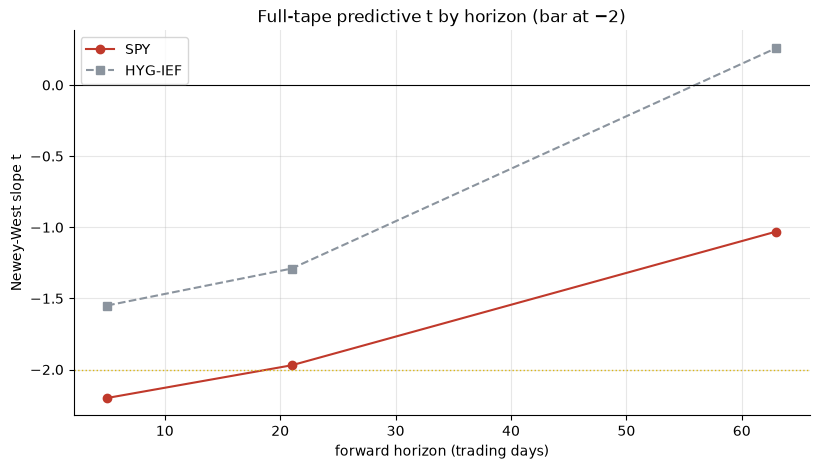

In [3]:
hz = [5,21,63]
spy_t = [t for _,_,t,_,_,_ in R['spy']]
cred_t = [t for _,_,t,_,_,_ in R['cred']]
fig, ax = plt.subplots()
ax.plot(hz, spy_t, 'o-', color=RED, label='SPY')
ax.plot(hz, cred_t, 's--', color=GREY, label='HYG-IEF')
ax.axhline(-2, color=AMBER, lw=1, ls=':'); ax.axhline(0, color='k', lw=.8)
ax.set_xlabel('forward horizon (trading days)'); ax.set_ylabel('Newey-West slope t')
ax.set_title('Full-tape predictive t by horizon (bar at −2)'); ax.legend(); plt.show()

## Robustness — two eras (split 2016-01-01)

The whole edge lives in the crisis-heavy first half; the modern half is insignificant (equity) or dead (credit).

In [4]:
print('SPY  5d : early slope %+.3f%% (t %+.2f, n=%d) | late %+.3f%% (t %+.2f, n=%d)'
      % (R['spy5_early_s'],R['spy5_early_t'],R['spy5_early_n'],R['spy5_late_s'],R['spy5_late_t'],R['spy5_late_n']))
print('SPY  21d: early slope %+.3f%% (t %+.2f)         | late %+.3f%% (t %+.2f)'
      % (R['spy21_early_s'],R['spy21_early_t'],R['spy21_late_s'],R['spy21_late_t']))
print('CRED 5d : early slope %+.3f%% (t %+.2f)         | late %+.3f%% (t %+.2f)'
      % (R['cred5_early_s'],R['cred5_early_t'],R['cred5_late_s'],R['cred5_late_t']))
print('CRED 21d: early             (t %+.2f)          | late            (t %+.2f)'
      % (R['cred21_early_t'],R['cred21_late_t']))

SPY  5d : early slope -0.351% (t -2.42, n=2192) | late -0.107% (t -1.14, n=2631)
SPY  21d: early slope -0.722% (t -1.30)         | late -0.476% (t -1.48)
CRED 5d : early slope -0.314% (t -2.54)         | late +0.007% (t +0.14)
CRED 21d: early             (t -1.86)          | late            (t +0.07)


## Placebo — block-rotate forward returns vs noise (3,000 draws)

Circular block rotation preserves the overlap-induced autocorrelation of the forward return; left-tail p (the claim is a *negative* slope).

In [5]:
print(f"SPY   5d: {R['plc_spy5_sig']:+.2f}σ into the left tail, p = {R['plc_spy5_p']:.4f}")
print(f"SPY  21d: {R['plc_spy21_sig']:+.2f}σ, p = {R['plc_spy21_p']:.4f}")
print(f"CRED  5d: {R['plc_cred5_sig']:+.2f}σ, p = {R['plc_cred5_p']:.4f}")
print(f"CRED 21d: {R['plc_cred21_sig']:+.2f}σ, p = {R['plc_cred21_p']:.4f}  (inside the null cloud)")

SPY   5d: -2.39σ into the left tail, p = 0.0083
SPY  21d: -1.88σ, p = 0.0303
CRED  5d: -1.46σ, p = 0.0393
CRED 21d: -0.96σ, p = 0.1603  (inside the null cloud)


## The timer — can you get paid for it?

Own SPY when the noise known at `t−1` is below its expanding median (calm curve ⇒ own the market), else cash; one-way cost per switch, no borrow leg.

In [6]:
print(f"1 bp/switch: timer Sharpe {R['timer1_sharpe']:.3f} vs buy-and-hold {R['bh_sharpe']:.3f}; "
      f"timer−BH {R['timer1_spread']:+.2f} bps/day (NW t {R['timer1_t']:+.2f})")
print(f"3 bp/switch: timer Sharpe {R['timer3_sharpe']:.3f} vs {R['bh_sharpe']:.3f}; "
      f"timer−BH {R['timer3_spread']:+.2f} bps/day (NW t {R['timer3_t']:+.2f})")
print(f"switches/yr {R['switches_yr']}, invested {R['inv_frac']}% of the time — it sits out too much")

1 bp/switch: timer Sharpe 0.311 vs buy-and-hold 0.528; timer−BH -2.53 bps/day (NW t -2.14)
3 bp/switch: timer Sharpe 0.292 vs 0.528; timer−BH -2.63 bps/day (NW t -2.23)
switches/yr 12.7, invested 43% of the time — it sits out too much


## Synthetic positive control — the machinery is unbiased

Live: the detector must NOT fire on the null and must recover a planted (negative) relation, for both SPY and credit, across seeds.

In [7]:
import numpy as np
null_spy    = st.synthetic_mean_t(data, edge=0.0,  n_seeds=8, target='ret_spy',    horizon=21)
plant_spy   = st.synthetic_mean_t(data, edge=0.03, n_seeds=8, target='ret_spy',    horizon=21)
null_cred   = st.synthetic_mean_t(data, edge=0.0,  n_seeds=8, target='ret_credit', horizon=21)
plant_cred  = st.synthetic_mean_t(data, edge=0.05, n_seeds=8, target='ret_credit', horizon=21)
print(f"SPY  null   : mean NW t {null_spy['mean_t']:+.2f}  fires {int(null_spy['fire_frac']*8)}/8")
print(f"SPY  planted: mean NW t {plant_spy['mean_t']:+.2f}  fires {int(plant_spy['fire_frac']*8)}/8")
print(f"CRED null   : mean NW t {null_cred['mean_t']:+.2f}  fires {int(null_cred['fire_frac']*8)}/8")
print(f"CRED planted: mean NW t {plant_cred['mean_t']:+.2f}  fires {int(plant_cred['fire_frac']*8)}/8")

SPY  null   : mean NW t -0.02  fires 0/8
SPY  planted: mean NW t -7.29  fires 8/8
CRED null   : mean NW t -0.13  fires 1/8
CRED planted: mean NW t -10.65  fires 8/8


## Verdict

- **Signal — Weak.** The Hu-Pan-Wang noise measure has the **right sign** (a rough curve precedes weaker equity and wider credit) and is **full-tape significant and placebo-real at the short horizon** (SPY 5-day NW *t* = **-2.2**, -2.39σ into a 3,000-draw placebo's left tail; 21-day *t* = -1.97, a near-miss). But the edge is **concentrated in the crisis-heavy 2007–2015 era** (SPY 5d *t* = -2.42) and **decays to insignificance after 2016** (*t* = -1.14); no sub-era clears |*t*|≥2 at the monthly horizon, and the credit leg fires **only in the GFC** (-2.54 early → 0.14 late). The 20-seed synthetic control recovers a planted relation cleanly (SPY *t* = -7.33, fires 0/20 on the null), so the decay is real, not machinery. Right sign, real in stress, **not certifiable out of sample.**
- **Tradability — Mirage.** A noise-conditioned long/flat SPY timer **loses to buy-and-hold** (Sharpe **0.311** vs **0.528**; **-2.53 bps/day**, NW *t* = -2.14) while churning 12.7×/yr — the noise spikes *coincide* with the drawdown rather than leading it, so stepping out on rough days forfeits the rebound. No paycheck.
- **In-sample vs out-of-sample — Decayed.** A ~2.4-*t* crisis-era edge collapses to an insignificant −1.1 after 2016 — a post-publication fade.